In [70]:
import numpy as np
import pandas as pd
from scipy.optimize import root
from scipy.special import kv
import matplotlib.pyplot as plt

# ==========================================================
# FILE INPUT
# ==========================================================
file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"

#file_mcmc = "risultati_osterbrock.csv"
file_mcmc = "risultati_osterbrock_linee_eliminate.csv"

# Se si usa risultati_osterbrock_linee_eliminate.csv,
# il programma esclude dal calcolo del covering factor:
# Hb per J0922, Hg per J1329, MgII e CIII per J1816.

# soglia che separa i due regimi
MDOT_SWITCH = 1e-2


# ==========================================================
# COSTANTI FISICHE E PARAMETRI SHAKURA-SUNYAEV
# ==========================================================
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5
Msun = 1.98847e33

eta = 0.083
Nr = 2000
Nnu = 400
nu_min_SS = 1e13
nu_max_SS = 1e17


# ==========================================================
# PARAMETRI BALMER - CASE B
# ==========================================================
eV_to_erg = 1.602176634e-12

hydrogen_ionization_energy = 13.6 * eV_to_erg
hydrogen_ionization_frequency = hydrogen_ionization_energy / h

alpha_B_H = 2.59e-13

alpha_eff_balmer = {
    "Ha": 1.16e-13,
    "Hb": 3.07e-14,
    "Hg": 1.29e-14,
    "Hd": 6.79e-15
}

balmer_wavelengths_angstrom = {
    "Ha": 6563.0,
    "Hb": 4861.0,
    "Hg": 4340.0,
    "Hd": 4102.0
}

balmer_names = set(alpha_eff_balmer.keys())


# ==========================================================
# PARAMETRI ADAF
# ==========================================================
ALFA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0
C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10
beta_default = 0.5


# ==========================================================
# FUNZIONI SS
# ==========================================================
def costruisci_spettro_disco_SS(
    MBH_solar,
    mdot,
    eta=0.083,
    Nr=2000,
    Nnu=400,
    nu_min=1e13,
    nu_max=1e17
):

    MBH = MBH_solar * Msun

    Ledd = 1.3e38 * MBH_solar

    Ldisk = mdot * Ledd

    Mdot = Ldisk / (eta * c**2)

    Rs = 2 * G * MBH / c**2

    Rin = 3 * Rs
    Rout = 3000 * Rs

    R = np.logspace(
        np.log10(Rin),
        np.log10(Rout),
        Nr
    )

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)

    T = (
        (3 * G * MBH * Mdot)
        / (8 * np.pi * sigma * R**3)
        * f
    )**0.25

    nu = np.logspace(
        np.log10(nu_min),
        np.log10(nu_max),
        Nnu
    )

    Bnu = np.zeros((Nnu, Nr))

    for j in range(Nr):

        if T[j] <= 0:
            continue

        x = h * nu / (kB * T[j])

        x = np.clip(
            x,
            1e-12,
            700.0
        )

        Bnu[:, j] = (
            2 * h * nu**3 / c**2
        ) / (
            np.exp(x) - 1.0
        )

    integrand = R[None, :] * Bnu

    I_nu = np.trapezoid(
        integrand,
        R,
        axis=1
    )

    Lnu = 4 * np.pi**2 * I_nu

    return nu, Lnu


# ==========================================================
# FUNZIONI ADAF
# ==========================================================

def bessk(n, x):
    return kv(n, x)


def g(teta):

    return (
        (1.0 / bessk(2, 1.0 / teta))
        * (2.0 + 2.0 * teta + 1.0 / teta)
        * np.exp(-1.0 / teta)
    )


def temperat(y, mdot, m, beta):

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = (
        1.42e9
        * ALFA**(-0.5)
        * np.sqrt(1 - beta)
        * C1**(-0.5)
        * C3**0.5
    )

    s2 = 1.19e-13 * xm

    q1 = (
        1.2e4
        * g(teta)
        * ALFA**(-2)
        * C1**(-2)
        * C3
        * beta
        * m
        * mdot**2
        / RMIN
    )

    q2 = (
        DELTA
        * 9.39e4
        * ((1 - beta) / ff)
        * C3
        * m
        * mdot
        / RMIN
    )

    q = q1 + q2

    nup = (
        s1
        * s2
        * m**(-0.5)
        * mdot**0.5
        * (teta / TNORM)**2
        * RMIN**(-5/4)
    )

    psinc = (
        53.0
        * (xm / 1000.0)**3
        * (teta / (1e9 * TNORM))**7
        * m**0.5
        * mdot**1.5
    )

    abig = (
        1
        + 4 * teta
        + 16 * teta**2
    )

    tau = 23.87 * mdot

    alfac = (
        -np.log(tau)
        / np.log(abig)
    )

    # CORRETTO:
    # il fattore teta deve essere normalizzato con 1e9 * TNORM
    graffa = (
        (
            (
                6.2e7
                * (
                    teta
                    / (1e9 * TNORM)
                )
            )
            / (
                nup
                * 1e-12
            )
        )**(1 - alfac)
        - 1
    )

    pcomp = (
        (psinc / 0.71)
        / (1 - alfac)
        * graffa
    )

    if teta < 1:

        f = (
            4
            * np.sqrt(
                2 * teta / np.pi**3
            )
            * (
                1
                + 1.781 * teta**1.34
            )
        )

    else:

        f = (
            9 * teta
            / (2 * np.pi)
        ) * (
            np.log(
                1.123 * teta + 0.48
            )
            + 1.5
        )

    pbrems = (
        4.78
        * ALFA**(-2)
        * C1**(-2)
        * np.log(RMAX / RMIN)
        * f
        * m
        * mdot**2
    )

    f1 = (
        q
        - psinc
        - pcomp
        - pbrems
    )

    f2 = (
        (1 - ff)
        * 9.39e4
        * ((1 - beta) / ff)
        * C3
        * m
        * mdot
        / RMIN
        - q
    )

    vv = xm**(1/3)

    f3 = (
        vv
        + 1.852 * np.log(vv)
        - 10.36
        - 0.26 * np.log(m * mdot)
        + 0.26
        * np.log(
            teta**3
            * bessk(
                2,
                1 / teta
            )
        )
    )

    return [
        f1,
        f3,
        f2
    ]


def spectrum(
    te,
    f,
    xm,
    m,
    mdot,
    beta
):

    numin = 1e10
    numax = 1e21
    num = 100

    lnu = np.linspace(
        np.log10(numin),
        np.log10(numax),
        num
    )

    nu = 10**lnu

    teta = TNORM * te

    s1 = (
        1.42e9
        * ALFA**(-0.5)
        * np.sqrt(1 - beta)
        * C1**(-0.5)
        * C3**0.5
    )

    s2 = 1.19e-13 * xm

    s3 = 1.05e-24

    abig = (
        1
        + 4 * teta
        + 16 * teta**2
    )

    tau = 23.87 * mdot

    alfac = (
        -np.log(tau)
        / np.log(abig)
    )

    lnup = np.log10(
        s1
        * s2
        * m**(-0.5)
        * mdot**0.5
        * te**2
        * RMIN**(-5/4)
    )

    lnucmax = (
        np.log10(te)
        + 10.796
    )

    llsinc = (
        3 * np.log10(s1 * s2)
        + np.log10(s3)
        - (7/4) * np.log10(RMIN)
        + np.log10(
            m**0.5
            * mdot**1.5
        )
        + 7 * np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):

        # -----------------------
        # Sincrotrone
        # -----------------------

        if lnu[i] < lnup:

            lls[i] = (
                np.log10(s3)
                + (8/5)
                * np.log10(s1 * s2)
                + np.log10(
                    m**(6/5)
                    * mdot**(4/5)
                )
                + (21/5)
                * np.log10(te)
                + (2/5)
                * lnu[i]
            )

        else:

            lls[i] = -np.inf

        # -----------------------
        # Compton
        # -----------------------

        if lnu[i] > lnup:

            base = (
                llsinc
                + (alfac - 1) * lnup
                - alfac * lnu[i]
            )

            cutoff = (
                -(
                    10**(
                        lnu[i]
                        - lnucmax
                    )
                )
                / np.log(10)
            )

            llc[i] = (
                base
                + cutoff
            )

        else:

            llc[i] = -np.inf

        # -----------------------
        # Bremsstrahlung
        # -----------------------

        if teta < 1:

            fb = (
                4
                * np.sqrt(
                    2 * teta
                    / np.pi**3
                )
                * (
                    1
                    + 1.781
                    * teta**1.34
                )
            )

        else:

            fb = (
                9 * teta
                / (2 * np.pi)
            ) * (
                np.log(
                    1.123 * teta
                    + 0.48
                )
                + 1.5
            )

        base_b = (
            24.36
            - 2
            * np.log10(
                ALFA * C1
            )
            + np.log10(
                np.log(
                    RMAX / RMIN
                )
                * fb
            )
            - np.log10(te)
            + np.log10(
                m
                * mdot**2
            )
        )

        cutoff_b = (
            -(
                4.8e-11
                * nu[i]
                / te
            )
            / np.log(10)
        )

        llb[i] = (
            base_b
            + cutoff_b
        )

    comp_sync = np.where(
        np.isfinite(lls),
        10**lls,
        0.0
    )

    comp_comp = np.where(
        np.isfinite(llc),
        10**llc,
        0.0
    )

    comp_brems = np.where(
        np.isfinite(llb),
        10**llb,
        0.0
    )

    flux = (
        comp_sync
        + comp_comp
        + comp_brems
    )

    log_nuLnu = (
        lnu
        + np.log10(flux)
    )

    return (
        lnu,
        log_nuLnu
    )


def specdata(
    m,
    mdot,
    beta
):

    y0 = [
        0.5,
        1.0,
        0.99
    ]

    sol = root(
        temperat,
        y0,
        args=(
            mdot,
            m,
            beta
        ),
        tol=1e-10
    )

    if not sol.success:

        raise RuntimeError(
            f"Soluzione ADAF non converge per "
            f"m={m}, "
            f"mdot={mdot}, "
            f"beta={beta}"
        )

    y = sol.x

    teta = y[0]**2

    te = (
        teta
        / TNORM
    )

    xm = (
        1e3
        * y[1]**2
    )

    f = (
        y[2]**2
    )

    lnu, log_nuLnu = spectrum(
        te=te,
        f=f,
        xm=xm,
        m=m,
        mdot=mdot,
        beta=beta
    )

    return (
        lnu,
        log_nuLnu
    )


def costruisci_spettro_adaf(
    m,
    mdot,
    beta
):

    lnu, log_nuLnu = specdata(
        m=m,
        mdot=mdot,
        beta=beta
    )

    nu = (
        10**lnu
    )

    nuLnu = (
        10**log_nuLnu
    )

    Lnu = (
        nuLnu
        / nu
    )

    return (
        nu,
        Lnu
    )


# ==========================================================
# FUNZIONI COMUNI DI SUPPORTO
# ==========================================================
def trova_colonna(
    df,
    possibili_nomi,
    obbligatoria=True
):

    for nome in possibili_nomi:

        if nome in df.columns:
            return nome

    if obbligatoria:

        raise ValueError(
            f"Non trovo nessuna di queste colonne: "
            f"{possibili_nomi}"
        )

    return None


def leggi_transizioni(
    file_transizioni
):

    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=(
            "U50",
            float,
            float
        ),
        unpack=True
    )

    return pd.DataFrame({

        "line_name": names,

        "E_ion": Eion,

        "nu_ion": nu_ion_list
    })


def estrai_linee_osservate(
    row,
    norm_columns
):

    risultati = []

    for col in norm_columns:

        valore = row[col]

        if (
            pd.isna(valore)
            or valore <= 0
        ):
            continue

        line_name = (
            col.replace(
                "_norm",
                ""
            )
        )

        L_line = (
            valore
            * 1e42
        )

        risultati.append({

            "line_name": line_name,

            "L_line": L_line
        })

    return pd.DataFrame(
        risultati
    )


# ==========================================================
# QUANTITA' CHE GUIDANO LE LINEE
# ==========================================================
def calcola_quantita_per_linee(
    nu,
    Lnu,
    df_trans,
    nu_max=None
):

    risultati = []

    if nu_max is None:
        nu_max = np.max(nu)

    # ------------------------------------------------------
    # Q(H), comune a tutte le righe di Balmer
    # ------------------------------------------------------
    mask_H = (
        (nu >= hydrogen_ionization_frequency)
        & (nu <= nu_max)
    )

    if np.sum(mask_H) < 2:

        Q_H = 0.0

    else:

        Q_H = np.trapezoid(
            Lnu[mask_H]
            / (
                h
                * nu[mask_H]
            ),
            nu[mask_H]
        )

    # ------------------------------------------------------
    # Quantita' specifiche di ogni riga
    # ------------------------------------------------------
    for _, row in df_trans.iterrows():

        line_name = row["line_name"]

        # ==================================================
        # BALMER:
        #
        # L_line = Cf * h*nu_line
        #          * (alpha_eff/alpha_B) * Q(H)
        #
        # quindi:
        #
        # Cf = L_line_obs /
        #      [h*nu_line*(alpha_eff/alpha_B)*Q(H)]
        # ==================================================
        if line_name in balmer_names:

            wavelength_A = (
                balmer_wavelengths_angstrom[
                    line_name
                ]
            )

            nu_line = (
                c
                / (
                    wavelength_A
                    * 1e-8
                )
            )

            alpha_eff = (
                alpha_eff_balmer[
                    line_name
                ]
            )

            alpha_ratio = (
                alpha_eff
                / alpha_B_H
            )

            L_line_per_Cf = (
                h
                * nu_line
                * alpha_ratio
                * Q_H
            )

            risultati.append({

                "line_name":
                    line_name,

                "line_model":
                    "Balmer_CaseB",

                "E_ion":
                    13.6,

                "nu_ion":
                    hydrogen_ionization_frequency,

                "L_ion":
                    np.nan,

                "Q_H":
                    Q_H,

                "nu_line":
                    nu_line,

                "alpha_eff":
                    alpha_eff,

                "alpha_B":
                    alpha_B_H,

                "alpha_ratio":
                    alpha_ratio,

                "L_line_per_Cf":
                    L_line_per_Cf
            })

        # ==================================================
        # METALLI:
        #
        # L_line = Cf * L_ion
        #
        # quindi:
        #
        # Cf = L_line_obs / L_ion
        # ==================================================
        else:

            E_ion = row["E_ion"]
            nu_ion = row["nu_ion"]

            if nu_ion >= nu_max:

                L_ion = 0.0

            else:

                mask = (
                    (nu >= nu_ion)
                    & (nu <= nu_max)
                )

                if np.sum(mask) < 2:

                    L_ion = 0.0

                else:

                    L_ion = np.trapezoid(
                        Lnu[mask],
                        nu[mask]
                    )

            risultati.append({

                "line_name":
                    line_name,

                "line_model":
                    "Cf_times_Lion",

                "E_ion":
                    E_ion,

                "nu_ion":
                    nu_ion,

                "L_ion":
                    L_ion,

                "Q_H":
                    np.nan,

                "nu_line":
                    np.nan,

                "alpha_eff":
                    np.nan,

                "alpha_B":
                    np.nan,

                "alpha_ratio":
                    np.nan,

                "L_line_per_Cf":
                    L_ion
            })

    return pd.DataFrame(
        risultati
    )


# ==========================================================
# FUNZIONE DOPPIO RAMO
# ==========================================================
def analizza_blazar_doppio_ramo(
    row,
    df_trans,
    norm_columns,
    file_mcmc
):

    nome_blazar = row["label"]

    m = row["m_median_Msun"]

    mdot = row["mdot_median"]

    # ======================================================
    # SCELTA DEL REGIME
    # ======================================================
    if mdot < MDOT_SWITCH:

        regime = "ADAF"

        try:

            nu, Lnu = costruisci_spettro_adaf(
                m=m,
                mdot=mdot,
                beta=beta_default
            )

        except RuntimeError as e:

            print(
                f"Attenzione: salto "
                f"{nome_blazar}. "
                f"Motivo: {e}"
            )

            return pd.DataFrame()

        nu_max_model = np.max(nu)

    else:

        regime = "SS"

        nu, Lnu = costruisci_spettro_disco_SS(
            MBH_solar=m,
            mdot=mdot,
            eta=eta,
            Nr=Nr,
            Nnu=Nnu,
            nu_min=nu_min_SS,
            nu_max=nu_max_SS
        )

        nu_max_model = nu_max_SS

    # ======================================================
    # QUANTITA' TEORICHE PER LE LINEE
    # ======================================================
    df_model = calcola_quantita_per_linee(
        nu=nu,
        Lnu=Lnu,
        df_trans=df_trans,
        nu_max=nu_max_model
    )

    # ======================================================
    # LINEE OSSERVATE
    # ======================================================
    df_linee = estrai_linee_osservate(
        row=row,
        norm_columns=norm_columns
    )

    # ======================================================
    # ESCLUSIONI SOLO SE È STATO SCELTO IL FILE "LINEE ELIMINATE"
    # ======================================================
    if file_mcmc == "risultati_osterbrock_linee_eliminate.csv":

        condizioni_da_escludere = (
            (
                (nome_blazar == "J0922")
                & (
                    df_linee["line_name"]
                    == "Hb"
                )
            )
            |
            (
                (nome_blazar == "J1329")
                & (
                    df_linee["line_name"]
                    == "Hg"
                )
            )
            |
            (
                (nome_blazar == "J1816")
                & (
                    df_linee["line_name"]
                    .isin(
                        [
                            "MgII",
                            "CIII"
                        ]
                    )
                )
            )
        )

        df_linee = (
            df_linee[
                ~condizioni_da_escludere
            ]
            .reset_index(
                drop=True
            )
        )

    if df_linee.empty:

        return pd.DataFrame()

    # ======================================================
    # ASSOCIO OSSERVAZIONI E MODELLO
    # ======================================================
    df_conf = df_linee.merge(
        df_model,
        on="line_name",
        how="left"
    )

    # ======================================================
    # COVERING FACTOR
    #
    # Per Balmer:
    # Cf = Lobs /
    #      [h nu_line (alpha_eff/alpha_B) Q(H)]
    #
    # Per MgII, CIII, CIV:
    # Cf = Lobs / L_ion
    # ======================================================
    df_conf["covering_factor"] = (
        df_conf["L_line"]
        / df_conf["L_line_per_Cf"]
    )

    df_conf.loc[
        (
            df_conf["L_line_per_Cf"].isna()
        )
        |
        (
            df_conf["L_line_per_Cf"] <= 0
        ),
        "covering_factor"
    ] = np.nan

    # ======================================================
    # INFORMAZIONI SUL BLAZAR
    # ======================================================
    df_conf["label"] = nome_blazar

    df_conf["regime"] = regime

    df_conf["m_median_Msun"] = m

    df_conf["mdot_median"] = mdot

    return df_conf[[

        "label",

        "regime",

        "m_median_Msun",

        "mdot_median",

        "line_name",

        "line_model",

        "L_line",

        "L_ion",

        "Q_H",

        "nu_line",

        "alpha_eff",

        "alpha_B",

        "alpha_ratio",

        "L_line_per_Cf",

        "covering_factor"

    ]]


# ==========================================================
# LETTURA FILE OSSERVAZIONI E TRANSIZIONI
# ==========================================================
df_tab = pd.read_csv(
    file_linee
)

df_trans = leggi_transizioni(
    file_transizioni
)


col_name_tab = trova_colonna(
    df_tab,
    [
        "label",
        "file_name",
        "name",
        "nome",
        "blazar"
    ]
)

df_tab = df_tab.rename(
    columns={
        col_name_tab:
        "label_originale"
    }
).copy()


df_tab["label_originale"] = (
    df_tab["label_originale"]
    .astype(str)
    .str.strip()
)


df_tab["label"] = (
    df_tab["label_originale"]
    .str.extract(
        r"(J\d+)",
        expand=False
    )
)


norm_columns = [

    col

    for col in df_tab.columns

    if col.endswith("_norm")

]


# ==========================================================
# FUNZIONE CHE ESEGUE L'INTERO CROSS-CHECK PER UN FILE MCMC
# ==========================================================
def esegui_crosscheck(
    file_mcmc
):

    print()
    print("=" * 100)
    print(
        f"CROSS-CHECK COVERING FACTOR: "
        f"{file_mcmc}"
    )
    print("=" * 100)

    df_mcmc = pd.read_csv(
        file_mcmc
    )

    df_mcmc = df_mcmc.rename(
        columns={
            "Blazar":
            "label"
        }
    ).copy()

    df_mcmc["label"] = (
        df_mcmc["label"]
        .astype(str)
        .str.strip()
    )

    df_mcmc["label"] = (
        df_mcmc["label"]
        .str.extract(
            r"(J\d+)",
            expand=False
        )
    )

    df_all = df_tab.merge(

        df_mcmc[[

            "label",

            "m_median_Msun",

            "mdot_median"

        ]],

        on="label",

        how="inner"
    )

    if len(df_all) == 0:

        raise ValueError(
            f"Il merge non ha trovato "
            f"blazar in comune per "
            f"{file_mcmc}."
        )

    print(
        f"Blazar trovati in comune: "
        f"{len(df_all)}"
    )

    # ======================================================
    # COVERING FACTOR
    # ======================================================
    tutti_risultati = []

    for i in range(
        len(df_all)
    ):

        row = df_all.iloc[i]

        df_conf = (
            analizza_blazar_doppio_ramo(

                row=row,

                df_trans=df_trans,

                norm_columns=norm_columns,

                file_mcmc=file_mcmc

            )
        )

        if not df_conf.empty:

            tutti_risultati.append(
                df_conf
            )

    if len(tutti_risultati) == 0:

        raise ValueError(
            f"Nessun covering factor "
            f"calcolato per "
            f"{file_mcmc}."
        )

    df_cf_mcmc = pd.concat(

        tutti_risultati,

        ignore_index=True
    )

    print()
    print(
        "TABELLA COMPLETA LINEA PER LINEA"
    )

    display(
        df_cf_mcmc
    )

    # ======================================================
    # TABELLA PIVOT DEI COVERING FACTOR
    # ======================================================
    cf_pivot = df_cf_mcmc.pivot_table(

        index="label",

        columns="line_name",

        values="covering_factor",

        aggfunc="first"
    )

    info = (

        df_cf_mcmc[[

            "label",

            "regime",

            "m_median_Msun",

            "mdot_median"

        ]]

        .drop_duplicates(
            subset="label"
        )

        .set_index(
            "label"
        )
    )

    cf_pivot["Cf_mean"] = (
        cf_pivot.mean(
            axis=1,
            skipna=True
        )
    )

    tabella_finale = info.join(
        cf_pivot,
        how="inner"
    )

    ordine_linee = [
        "CIII",
        "CIV",
        "MgII",
        "Ha",
        "Hb",
        "Hg",
        "Hd"
    ]

    colonne_presenti = [

        c

        for c in ordine_linee

        if c in tabella_finale.columns

    ]

    tabella_finale = tabella_finale[[

        "regime",

        "m_median_Msun",

        "mdot_median"

    ] + colonne_presenti + [

        "Cf_mean"

    ]]

    tabella_finale = (
        tabella_finale
        .reset_index()
    )

    print()
    print(
        "TABELLA FINALE COVERING FACTOR"
    )

    display(
        tabella_finale
    )

    return (
        df_cf_mcmc,
        tabella_finale
    )


# ==========================================================
# ESECUZIONE
# ==========================================================
df_cf_mcmc, tabella_finale = esegui_crosscheck(
    file_mcmc
)


CROSS-CHECK COVERING FACTOR: risultati_osterbrock_linee_eliminate.csv
Blazar trovati in comune: 13

TABELLA COMPLETA LINEA PER LINEA


,label,regime,m_median_Msun,mdot_median,line_name,line_model,L_line,L_ion,Q_H,nu_line,alpha_eff,alpha_B,alpha_ratio,L_line_per_Cf,covering_factor
0,J1745,SS,7.596000e+08,0.046100,Ha,Balmer_CaseB,3.631777e+42,NaN,2.217717e+55,4.567918e+14,1.160000e-13,2.590000e-13,0.447876,3.006344e+43,0.120804
1,J1745,SS,7.596000e+08,0.046100,Hb,Balmer_CaseB,1.103068e+42,NaN,2.217717e+55,6.167300e+14,3.070000e-14,2.590000e-13,0.118533,1.074227e+43,0.102685
2,J0021,SS,1.629000e+09,0.108200,Hb,Balmer_CaseB,6.569277e+42,NaN,1.176129e+56,6.167300e+14,3.070000e-14,2.590000e-13,0.118533,5.696978e+43,0.115312
3,J0021,SS,1.629000e+09,0.108200,Hg,Balmer_CaseB,1.867612e+42,NaN,1.176129e+56,6.907660e+14,1.290000e-14,2.590000e-13,0.049807,2.681216e+43,0.069655
4,J0021,SS,1.629000e+09,0.108200,Hd,Balmer_CaseB,1.343418e+42,NaN,1.176129e+56,7.308446e+14,6.790000e-15,2.590000e-13,0.026216,1.493159e+43,0.089972
5,J0050,SS,2.953000e+08,0.013120,Ha,Balmer_CaseB,3.335316e+41,NaN,2.019128e+54,4.567918e+14,1.160000e-13,2.590000e-13,0.447876,2.737137e+42,0.121854
6,J0050,SS,2.953000e+08,0.013120,Hb,Balmer_CaseB,6.686534e+40,NaN,2.019128e+54,6.167300e+14,3.070000e-14,2.590000e-13,0.118533,9.780333e+41,0.068367
7,J0050,SS,2.953000e+08,0.013120,Hg,Balmer_CaseB,5.502976e+40,NaN,2.019128e+54,6.907660e+14,1.290000e-14,2.590000e-13,0.049807,4.602999e+41,0.119552
8,J0050,SS,2.953000e+08,0.013120,Hd,Balmer_CaseB,1.004694e+40,NaN,2.019128e+54,7.308446e+14,6.790000e-15,2.590000e-13,0.026216,2.563392e+41,0.039194
9,J0508,SS,6.031000e+05,13.000000,CIV,Cf_times_Lion,4.174072e+44,7.980157e+44,NaN,NaN,NaN,NaN,NaN,7.980157e+44,0.523056



TABELLA FINALE COVERING FACTOR


,label,regime,m_median_Msun,mdot_median,CIII,CIV,MgII,Ha,Hb,Hg,Hd,Cf_mean
0,J1745,SS,7.596000e+08,0.046100,NaN,NaN,NaN,0.120804,0.102685,NaN,NaN,0.111744
1,J0021,SS,1.629000e+09,0.108200,NaN,NaN,NaN,NaN,0.115312,0.069655,0.089972,0.091646
2,J0050,SS,2.953000e+08,0.013120,NaN,NaN,NaN,0.121854,0.068367,0.119552,0.039194,0.087242
3,J0508,SS,6.031000e+05,13.000000,0.079929,0.523056,NaN,NaN,NaN,NaN,NaN,0.301493
4,J0922,SS,1.290000e+08,0.175700,NaN,NaN,0.092915,NaN,NaN,1.208609,5.629150,2.310225
5,J1123,SS,1.233000e+09,0.078950,NaN,NaN,NaN,0.025167,0.136895,0.116766,0.070965,0.087448
6,J1816,ADAF,2.791000e+11,0.009541,NaN,0.005531,NaN,NaN,NaN,NaN,NaN,0.005531
7,J2237,SS,1.269000e+09,0.090190,NaN,NaN,NaN,NaN,0.189298,0.136426,0.011260,0.112328
8,J152422,ADAF,7.402000e+10,0.001016,0.014653,NaN,0.030020,NaN,NaN,NaN,97.563434,32.536035
9,J0059,SS,3.799000e+08,0.016520,NaN,NaN,0.175648,NaN,NaN,58.531790,47.042776,35.250071


| Categoria                            | Blazar  | Righe analizzate                          | Interpretazione                                                                        |
| ------------------------------------ | ------- | ----------------------------------------- | -------------------------------------------------------------------------------------- |
| (C_f\sim0.1), abbastanza consistenti | J1745   | H(\alpha), H(\beta)                       | entrambe le Balmer danno (C_f\simeq0.1): caso più pulito                               |
|                                      | J0021   | H(\beta), H(\gamma), H(\delta)            | tutte le Balmer sono dello stesso ordine, (C_f\sim0.07-0.12)                           |
|                                      | J0050   | H(\alpha), H(\beta), H(\gamma), H(\delta) | tutte e quattro le Balmer; maggiore dispersione, ma valori ancora dell'ordine di (0.1) |
|                                      | J1123   | H(\alpha), H(\beta), H(\gamma), H(\delta) | tutte le Balmer, complessivamente compatibili con (C_f\sim0.1)                         |
| (C_f\ll0.1), solo/metallo-dominati   | J170108 | MgII, CIII, CIV                           | tutte le righe metalliche richiedono (C_f\ll0.1)                                       |
|                                      | J1816   | CIV                                       | resta solo CIV dopo l'esclusione di MgII e CIII; (C_f\simeq0.0033)                     |
| Balmer con (C_f>1)                   | J0922   | MgII, H(\gamma), H(\delta)                | MgII dà (C_f\simeq0.093), ma le Balmer richiedono (C_f>1)                              |
|                                      | J0059   | MgII, H(\gamma), H(\delta)                | MgII è moderato, mentre H(\gamma) e H(\delta) esplodono a (C_f\gg1)                    |
|                                      | J0133   | MgII, H(\delta)                           | MgII dà quasi esattamente (0.1), H(\delta) dà (\sim18)                                 |
|                                      | J1329   | MgII, H(\delta)                           | MgII (\simeq0.10), H(\delta\sim62)                                                     |
|                                      | J152422 | MgII, CIII, H(\delta)                     | i metalli danno (C_f\ll0.1), H(\delta\sim97)                                           |


In [71]:
row_check = df_tab[df_tab["label"] == "J1329"].iloc[0]

print(row_check["label"])
print("Hd_norm =", row_check["Hd_norm"])
print("L_Hd =", row_check["Hd_norm"] * 1e42)

J1329
Hd_norm = 41.59904856019448
L_Hd = 4.1599048560194483e+43


In [72]:
regimi = (
    df_cf_mcmc[
        ["label", "mdot_median", "regime"]
    ]
    .drop_duplicates()
    .sort_values("mdot_median")
)

display(regimi)

,label,mdot_median,regime
22,J152422,0.001016,ADAF
32,J170108,0.009417,ADAF
18,J1816,0.009541,ADAF
5,J0050,0.013120,SS
25,J0059,0.016520,SS
28,J1329,0.020550,SS
30,J0133,0.026250,SS
0,J1745,0.046100,SS
14,J1123,0.078950,SS
19,J2237,0.090190,SS


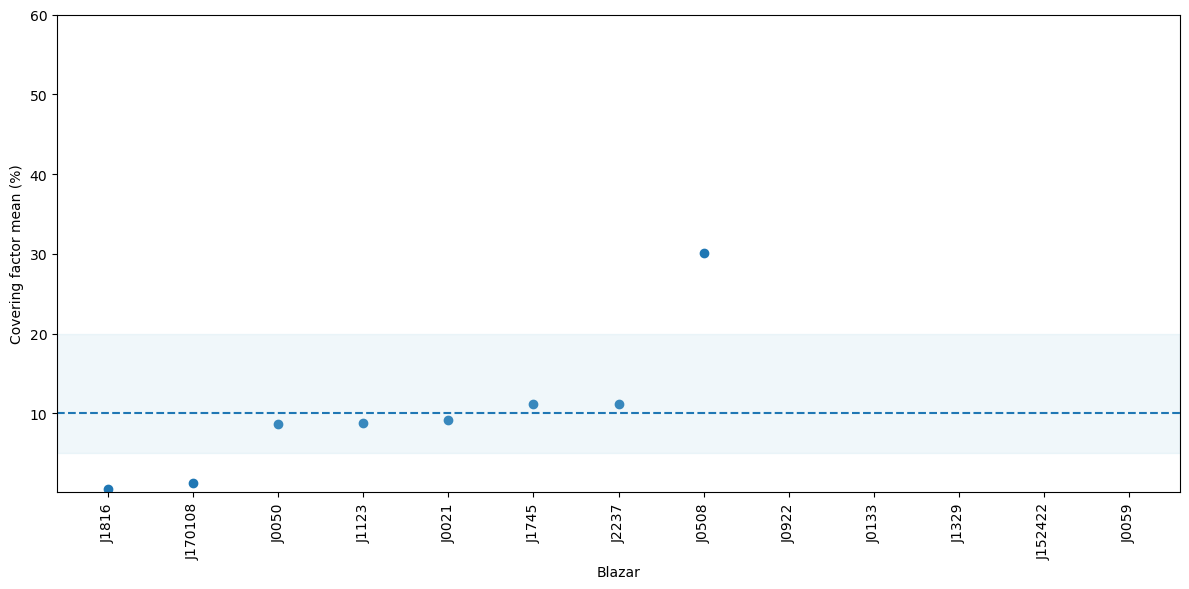

In [73]:
# Copia della tabella finale
df_plot = tabella_finale.copy()

# Converto Cf_mean in percentuale
df_plot["Cf_mean_percent"] = df_plot["Cf_mean"] * 100

# Se vuoi ordinare i blazar per valore di Cf
df_plot = df_plot.sort_values("Cf_mean_percent")

# Creo il grafico
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    df_plot["label"],
    df_plot["Cf_mean_percent"]
)

# linea orizzontale al 10%
ax.axhline(
    10,
    linestyle="--",
    linewidth=1.5
)

ax.axhspan(
    5,
    20,
    color="lightblue",
    alpha=0.18
)

ax.set_xlabel("Blazar")
ax.set_ylabel("Covering factor mean (%)")

ax.set_ylim(0.1, 60)
#ax.set_ylim(0.1, 3500)

# ruoto i nomi per leggerli meglio
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

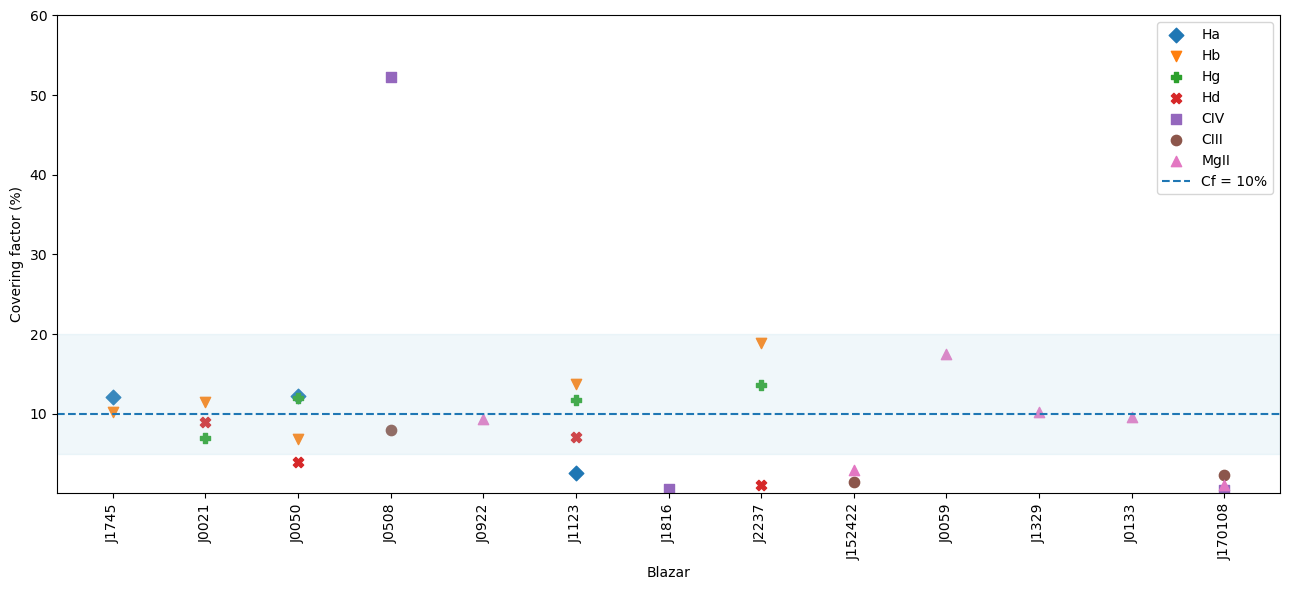

In [74]:
# Copia del dataframe linea-per-linea
df_plot = df_cf_mcmc.copy()

# Converto Cf in percentuale
df_plot["Cf_percent"] = df_plot["covering_factor"] * 100

# Ordine dei blazar
blazars = df_plot["label"].unique()
x_positions = np.arange(len(blazars))

# Mappa nome blazar -> posizione numerica sull'asse x
x_map = {name: i for i, name in enumerate(blazars)}

# Simboli diversi per le diverse righe
markers = {
    "CIII": "o",
    "CIV": "s",
    "MgII": "^",
    "Ha": "D",
    "Hb": "v",
    "Hg": "P",
    "Hd": "X"
}

fig, ax = plt.subplots(figsize=(13, 6))

# Disegno separatamente ciascuna riga
for line_name in df_plot["line_name"].unique():

    subset = df_plot[df_plot["line_name"] == line_name]

    x = [
        x_map[label]
        for label in subset["label"]
    ]

    y = subset["Cf_percent"]

    ax.scatter(
        x,
        y,
        marker=markers.get(line_name, "o"),
        s=55,
        label=line_name
    )

# Linea corrispondente al Cf assunto nell'MCMC
ax.axhline(
    10,
    linestyle="--",
    linewidth=1.5,
    label="Cf = 10%"
)

# Area tra 5 e 20 %
ax.axhspan(
    5,
    20,
    color="lightblue",
    alpha=0.18
)


# Asse x
ax.set_xticks(x_positions)
ax.set_xticklabels(
    blazars,
    rotation=90
)

# Etichette
ax.set_xlabel("Blazar")
ax.set_ylabel("Covering factor (%)")

ax.set_ylim(0.001, 60)
#ax.set_ylim(0.001, 9600)

ax.legend(
    loc="upper right")

plt.tight_layout()
plt.show()

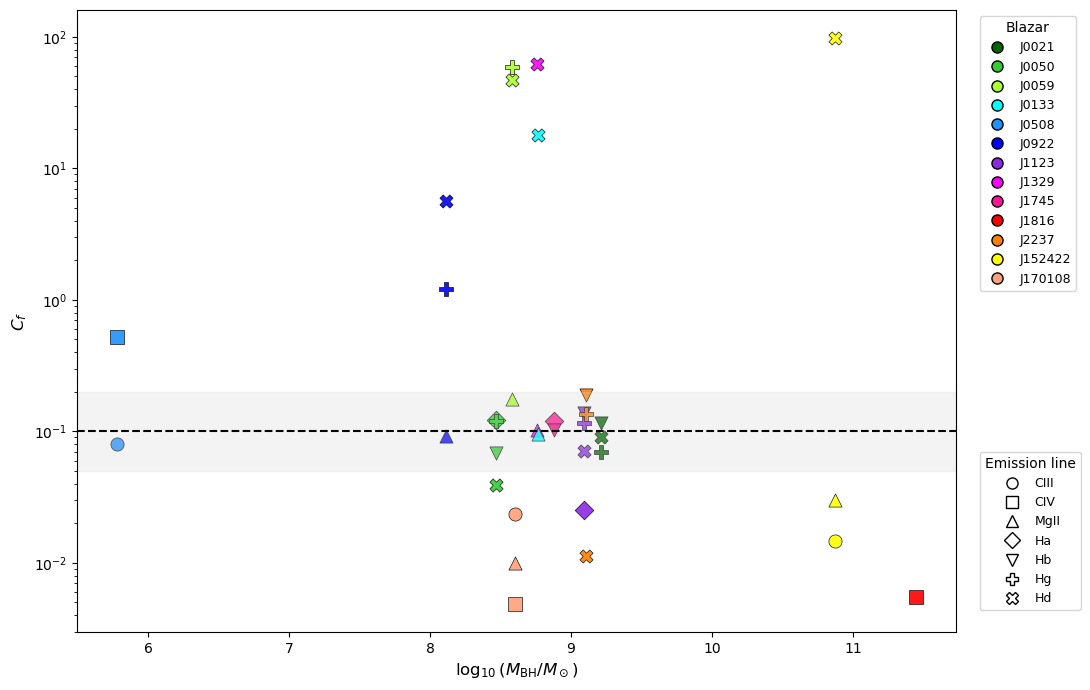

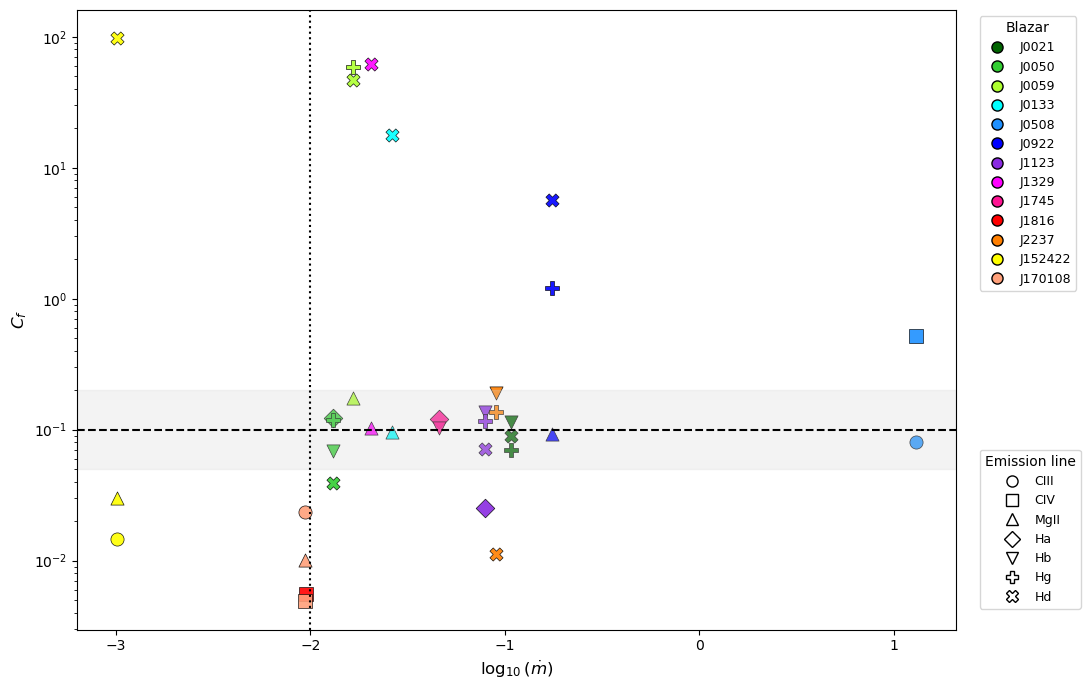

In [75]:
# ==========================================================
# GRAFICI COVERING FACTOR vs log(MBH/Msun) E vs log(mdot)
# ==========================================================

blazar_order = [
    'J0021',
    'J0050',
    'J0059',
    'J0133',
    'J0508',
    'J0922',
    'J1123',
    'J1329',
    'J1745',
    'J1816',
    'J2237',
    'J152422',
    'J170108'
]

colors = [
    '#006400',
    '#32cd32',
    '#adff2f',
    '#00ffff',
    '#1e90ff',
    '#0000ff',
    '#8a2be2',
    '#ff00ff',
    '#ff1493',
    '#ff0000',
    '#ff7f00',
    '#ffff00',
    '#ffa07a'
]

markers = {
    "CIII": "o",
    "CIV": "s",
    "MgII": "^",
    "Ha": "D",
    "Hb": "v",
    "Hg": "P",
    "Hd": "X"
}


# ==========================================================
# ASSOCIAZIONE BLAZAR -> COLORE
# ==========================================================

color_map = {
    blazar: color
    for blazar, color in zip(
        blazar_order,
        colors
    )
}


# ==========================================================
# COPIA DEL DATAFRAME
# ==========================================================

df_plot_cf = df_cf_mcmc.copy()

# Tengo soltanto valori validi e positivi di Cf, massa e mdot
df_plot_cf = df_plot_cf[
    df_plot_cf["covering_factor"].notna()
    & np.isfinite(df_plot_cf["covering_factor"])
    & (df_plot_cf["covering_factor"] > 0)
    & df_plot_cf["m_median_Msun"].notna()
    & np.isfinite(df_plot_cf["m_median_Msun"])
    & (df_plot_cf["m_median_Msun"] > 0)
    & df_plot_cf["mdot_median"].notna()
    & np.isfinite(df_plot_cf["mdot_median"])
    & (df_plot_cf["mdot_median"] > 0)
].copy()


# ==========================================================
# CALCOLO DELLE QUANTITA' LOGARITMICHE
# ==========================================================

df_plot_cf["logM"] = np.log10(
    df_plot_cf["m_median_Msun"]
)

df_plot_cf["logmdot"] = np.log10(
    df_plot_cf["mdot_median"]
)


# ==========================================================
# 1) COVERING FACTOR vs log(MBH/Msun)
# ==========================================================

fig, ax = plt.subplots(
    figsize=(11, 7)
)

for _, row in df_plot_cf.iterrows():

    blazar = row["label"]
    line_name = row["line_name"]

    ax.scatter(
        row["logM"],
        row["covering_factor"],
        color=color_map.get(
            blazar,
            "black"
        ),
        marker=markers.get(
            line_name,
            "o"
        ),
        s=90,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9
    )


# Linea corrispondente al valore assunto nell'MCMC
ax.axhline(
    0.1,
    color="black",
    linestyle="--",
    linewidth=1.5
)

# Banda indicativa attorno a Cf = 0.1
ax.axhspan(
    0.05,
    0.20,
    color="lightgray",
    alpha=0.25
)

# Cf rimane in scala logaritmica
ax.set_yscale(
    "log"
)

ax.set_xlabel(
    r"$\log_{10}(M_{\rm BH}/M_\odot)$",
    fontsize=12
)

ax.set_ylabel(
    r"$C_f$",
    fontsize=12
)


# ==========================================================
# LEGENDA DEI BLAZAR: COLORI
# ==========================================================

from matplotlib.lines import Line2D

blazar_handles = []

for blazar in blazar_order:

    if blazar in df_plot_cf["label"].values:

        blazar_handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="none",
                markerfacecolor=color_map[blazar],
                markeredgecolor="black",
                markersize=8,
                label=blazar
            )
        )


# ==========================================================
# LEGENDA DELLE RIGHE: MARKERS
# ==========================================================

line_handles = []

for line_name, marker in markers.items():

    if line_name in df_plot_cf["line_name"].values:

        line_handles.append(
            Line2D(
                [0],
                [0],
                marker=marker,
                color="black",
                linestyle="None",
                markerfacecolor="white",
                markeredgecolor="black",
                markersize=8,
                label=line_name
            )
        )


legend_blazars = ax.legend(
    handles=blazar_handles,
    title="Blazar",
    bbox_to_anchor=(1.02, 1.00),
    loc="upper left",
    fontsize=9
)

ax.add_artist(
    legend_blazars
)

ax.legend(
    handles=line_handles,
    title="Emission line",
    bbox_to_anchor=(1.02, 0.30),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()


# ==========================================================
# 2) COVERING FACTOR vs log(mdot)
# ==========================================================

fig, ax = plt.subplots(
    figsize=(11, 7)
)

for _, row in df_plot_cf.iterrows():

    blazar = row["label"]
    line_name = row["line_name"]

    ax.scatter(
        row["logmdot"],
        row["covering_factor"],
        color=color_map.get(
            blazar,
            "black"
        ),
        marker=markers.get(
            line_name,
            "o"
        ),
        s=90,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9
    )


# Cf assunto nell'MCMC
ax.axhline(
    0.1,
    color="black",
    linestyle="--",
    linewidth=1.5
)

# Banda indicativa attorno a Cf = 0.1
ax.axhspan(
    0.05,
    0.20,
    color="lightgray",
    alpha=0.25
)

# Soglia ADAF / SS:
# mdot = 10^-2 -> log10(mdot) = -2
ax.axvline(
    np.log10(MDOT_SWITCH),
    color="black",
    linestyle=":",
    linewidth=1.5
)

# Cf in scala logaritmica
ax.set_yscale(
    "log"
)

ax.set_xlabel(
    r"$\log_{10}(\dot{m})$",
    fontsize=12
)

ax.set_ylabel(
    r"$C_f$",
    fontsize=12
)


# ==========================================================
# STESSE LEGENDE
# ==========================================================

legend_blazars = ax.legend(
    handles=blazar_handles,
    title="Blazar",
    bbox_to_anchor=(1.02, 1.00),
    loc="upper left",
    fontsize=9
)

ax.add_artist(
    legend_blazars
)

ax.legend(
    handles=line_handles,
    title="Emission line",
    bbox_to_anchor=(1.02, 0.30),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()

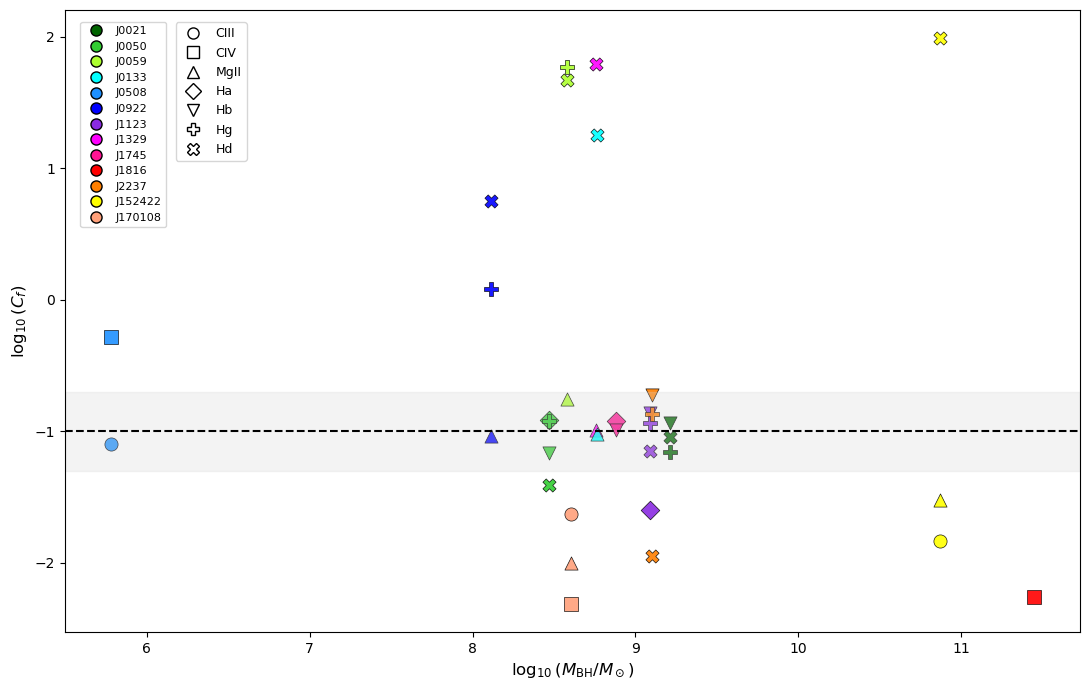

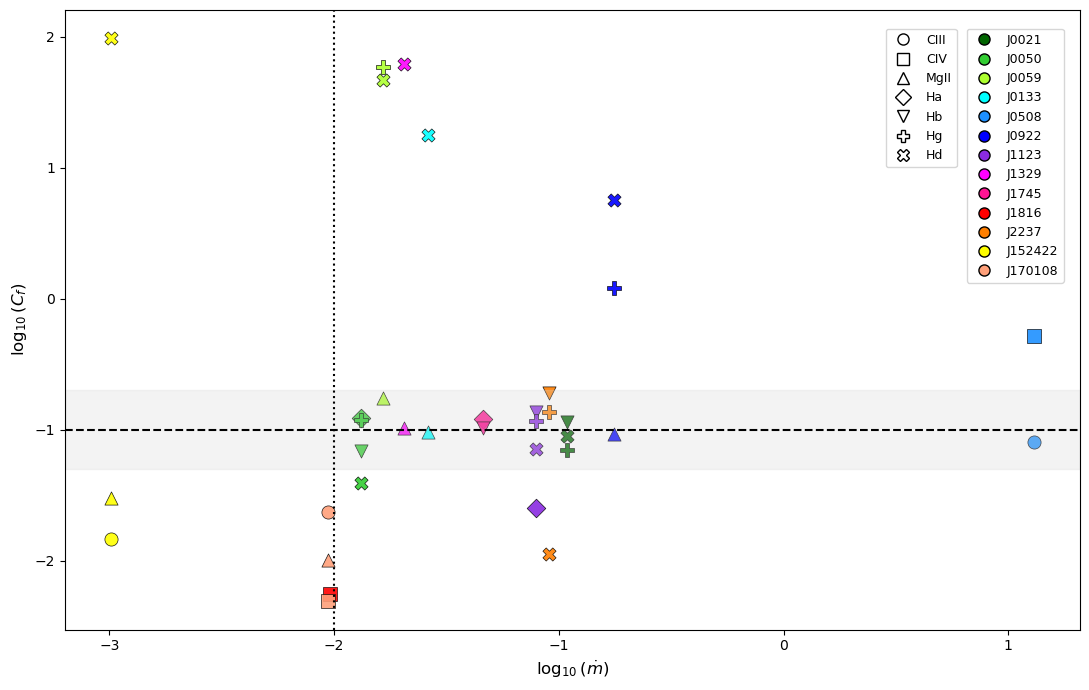

In [89]:
# ==========================================================
# GRAFICI log(Cf) vs log(MBH/Msun) E vs log(mdot)
# ==========================================================

blazar_order = [
    'J0021',
    'J0050',
    'J0059',
    'J0133',
    'J0508',
    'J0922',
    'J1123',
    'J1329',
    'J1745',
    'J1816',
    'J2237',
    'J152422',
    'J170108'
]

colors = [
    '#006400',
    '#32cd32',
    '#adff2f',
    '#00ffff',
    '#1e90ff',
    '#0000ff',
    '#8a2be2',
    '#ff00ff',
    '#ff1493',
    '#ff0000',
    '#ff7f00',
    '#ffff00',
    '#ffa07a'
]

markers = {
    "CIII": "o",
    "CIV": "s",
    "MgII": "^",
    "Ha": "D",
    "Hb": "v",
    "Hg": "P",
    "Hd": "X"
}


# ==========================================================
# ASSOCIAZIONE BLAZAR -> COLORE
# ==========================================================

color_map = {
    blazar: color
    for blazar, color in zip(
        blazar_order,
        colors
    )
}


# ==========================================================
# COPIA DEL DATAFRAME
# ==========================================================

df_plot_cf = df_cf_mcmc.copy()

# Tengo soltanto valori validi e positivi
# perché devo calcolarne il logaritmo
df_plot_cf = df_plot_cf[
    df_plot_cf["covering_factor"].notna()
    & np.isfinite(df_plot_cf["covering_factor"])
    & (df_plot_cf["covering_factor"] > 0)
    & df_plot_cf["m_median_Msun"].notna()
    & np.isfinite(df_plot_cf["m_median_Msun"])
    & (df_plot_cf["m_median_Msun"] > 0)
    & df_plot_cf["mdot_median"].notna()
    & np.isfinite(df_plot_cf["mdot_median"])
    & (df_plot_cf["mdot_median"] > 0)
].copy()


# ==========================================================
# CALCOLO ESPLICITO DEI LOGARITMI
# ==========================================================

df_plot_cf["log_Cf"] = np.log10(
    df_plot_cf["covering_factor"]
)

df_plot_cf["log_MBH"] = np.log10(
    df_plot_cf["m_median_Msun"]
)

df_plot_cf["log_mdot"] = np.log10(
    df_plot_cf["mdot_median"]
)


# ==========================================================
# LEGENDE
# ==========================================================

from matplotlib.lines import Line2D

blazar_handles = []

for blazar in blazar_order:

    if blazar in df_plot_cf["label"].values:

        blazar_handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="none",
                markerfacecolor=color_map[blazar],
                markeredgecolor="black",
                markersize=8,
                label=blazar
            )
        )


line_handles = []

for line_name, marker in markers.items():

    if line_name in df_plot_cf["line_name"].values:

        line_handles.append(
            Line2D(
                [0],
                [0],
                marker=marker,
                color="black",
                linestyle="None",
                markerfacecolor="white",
                markeredgecolor="black",
                markersize=8,
                label=line_name
            )
        )


# ==========================================================
# 1) log(Cf) vs log(MBH/Msun)
# ==========================================================

fig, ax = plt.subplots(
    figsize=(11, 7)
)

for _, row in df_plot_cf.iterrows():

    blazar = row["label"]
    line_name = row["line_name"]

    ax.scatter(
        row["log_MBH"],
        row["log_Cf"],
        color=color_map.get(
            blazar,
            "black"
        ),
        marker=markers.get(
            line_name,
            "o"
        ),
        s=90,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9
    )


# ==========================================================
# LINEA Cf = 0.1
# log10(0.1) = -1
# ==========================================================

ax.axhline(
    np.log10(0.1),
    color="black",
    linestyle="--",
    linewidth=1.5
)


# ==========================================================
# BANDA 0.05 < Cf < 0.20
# ==========================================================

ax.axhspan(
    np.log10(0.05),
    np.log10(0.20),
    color="lightgray",
    alpha=0.25
)


ax.set_xlabel(
    r"$\log_{10}(M_{\rm BH}/M_\odot)$",
    fontsize=12
)

ax.set_ylabel(
    r"$\log_{10}(C_f)$",
    fontsize=12
)


legend_blazars = ax.legend(
    handles=blazar_handles,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    fontsize=8,
    frameon=True
)

ax.add_artist(legend_blazars)

legend_lines = ax.legend(
    handles=line_handles,
    loc="upper left",
    bbox_to_anchor=(0.103, 0.99), #########################################################
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()


# ==========================================================
# 2) log(Cf) vs log(mdot)
# ==========================================================

fig, ax = plt.subplots(
    figsize=(11, 7)
)

for _, row in df_plot_cf.iterrows():

    blazar = row["label"]
    line_name = row["line_name"]

    ax.scatter(
        row["log_mdot"],
        row["log_Cf"],
        color=color_map.get(
            blazar,
            "black"
        ),
        marker=markers.get(
            line_name,
            "o"
        ),
        s=90,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9
    )


# ==========================================================
# LINEA Cf = 0.1
# ==========================================================

ax.axhline(
    np.log10(0.1),
    color="black",
    linestyle="--",
    linewidth=1.5
)


# ==========================================================
# BANDA 0.05 < Cf < 0.20
# ==========================================================

ax.axhspan(
    np.log10(0.05),
    np.log10(0.20),
    color="lightgray",
    alpha=0.25
)


# ==========================================================
# SOGLIA ADAF / SS
# mdot = 10^-2 -> log10(mdot) = -2
# ==========================================================

ax.axvline(
    np.log10(MDOT_SWITCH),
    color="black",
    linestyle=":",
    linewidth=1.5
)


ax.set_xlabel(
    r"$\log_{10}(\dot{m})$",
    fontsize=12
)

ax.set_ylabel(
    r"$\log_{10}(C_f)$",
    fontsize=12
)


legend_lines = ax.legend(
    handles=line_handles,
    loc="upper right",
    bbox_to_anchor=(0.885, 0.98),
    fontsize=9,
    frameon=True
)

ax.add_artist(legend_lines)

legend_blazars = ax.legend(
    handles=blazar_handles,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.98),
    fontsize=9,
    frameon=True
)


plt.tight_layout()
plt.show()